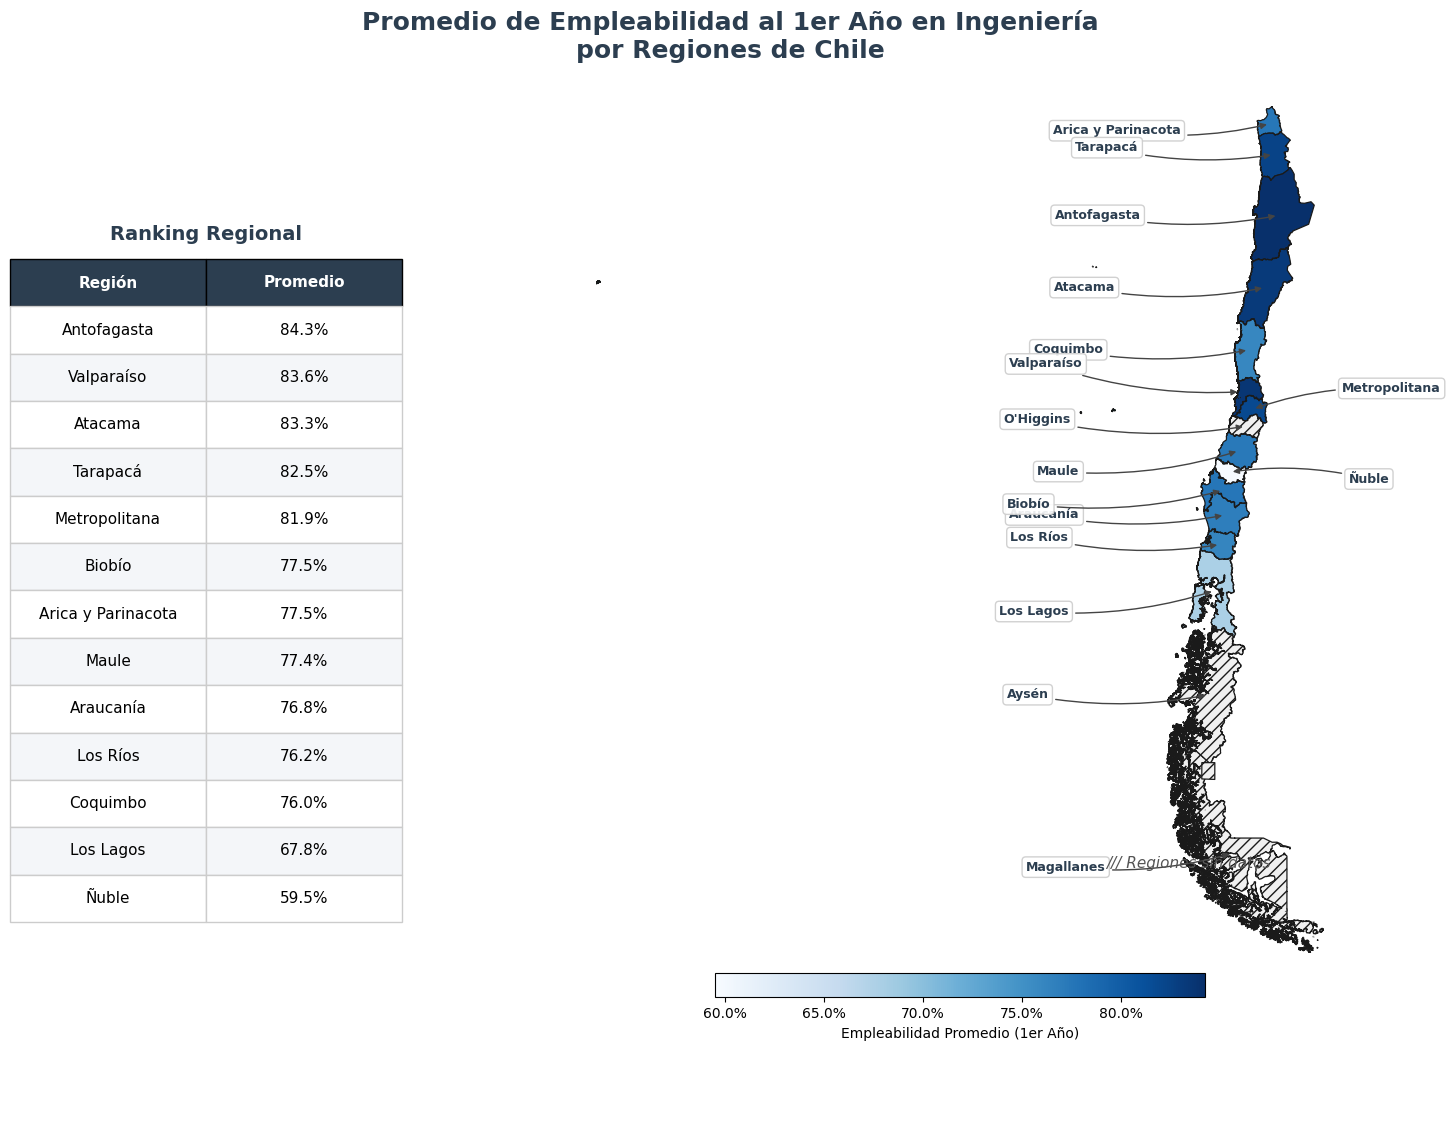

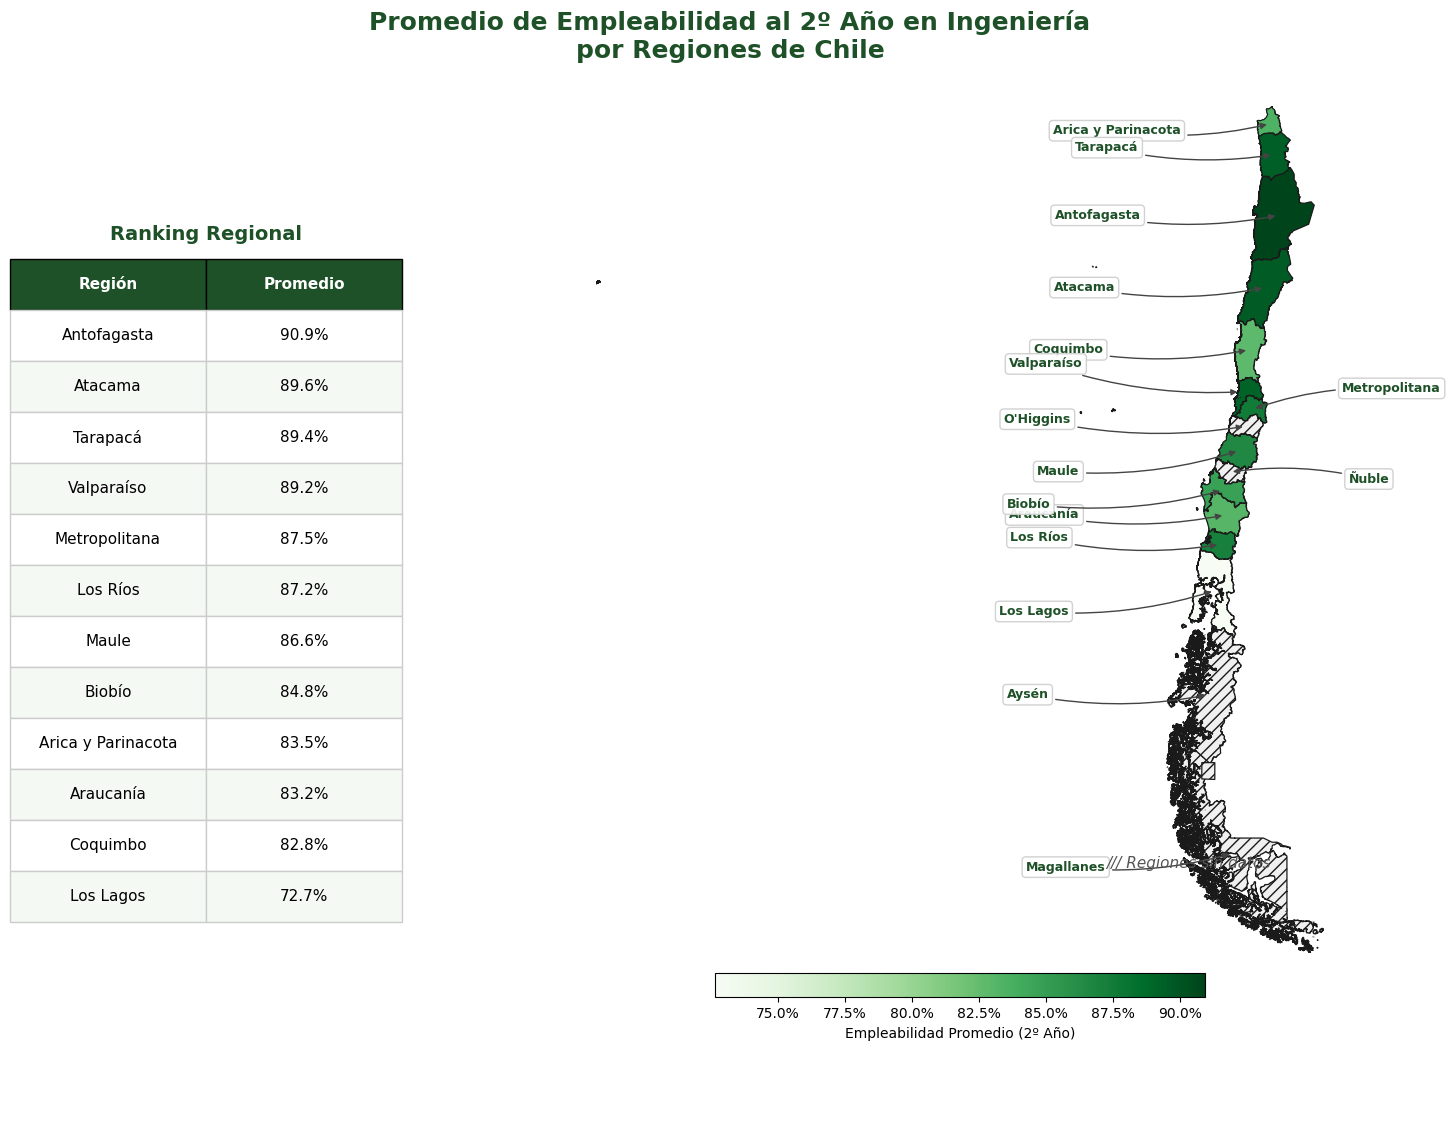

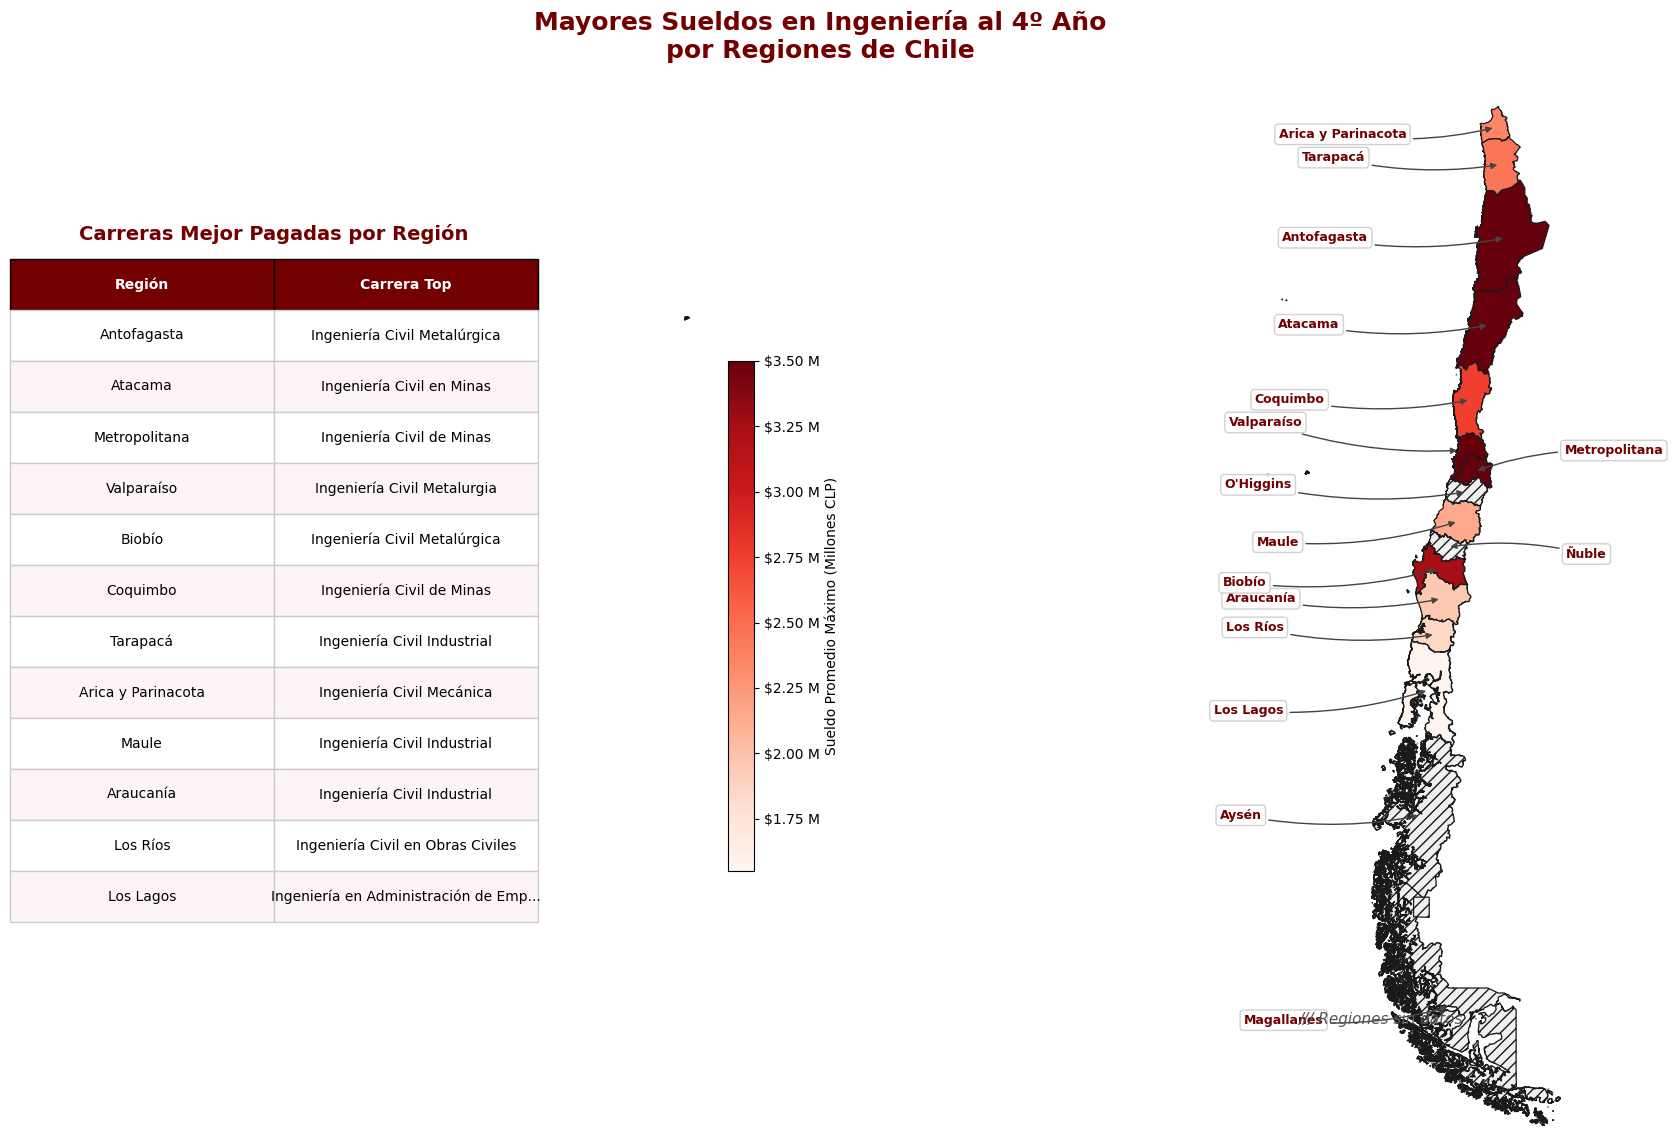

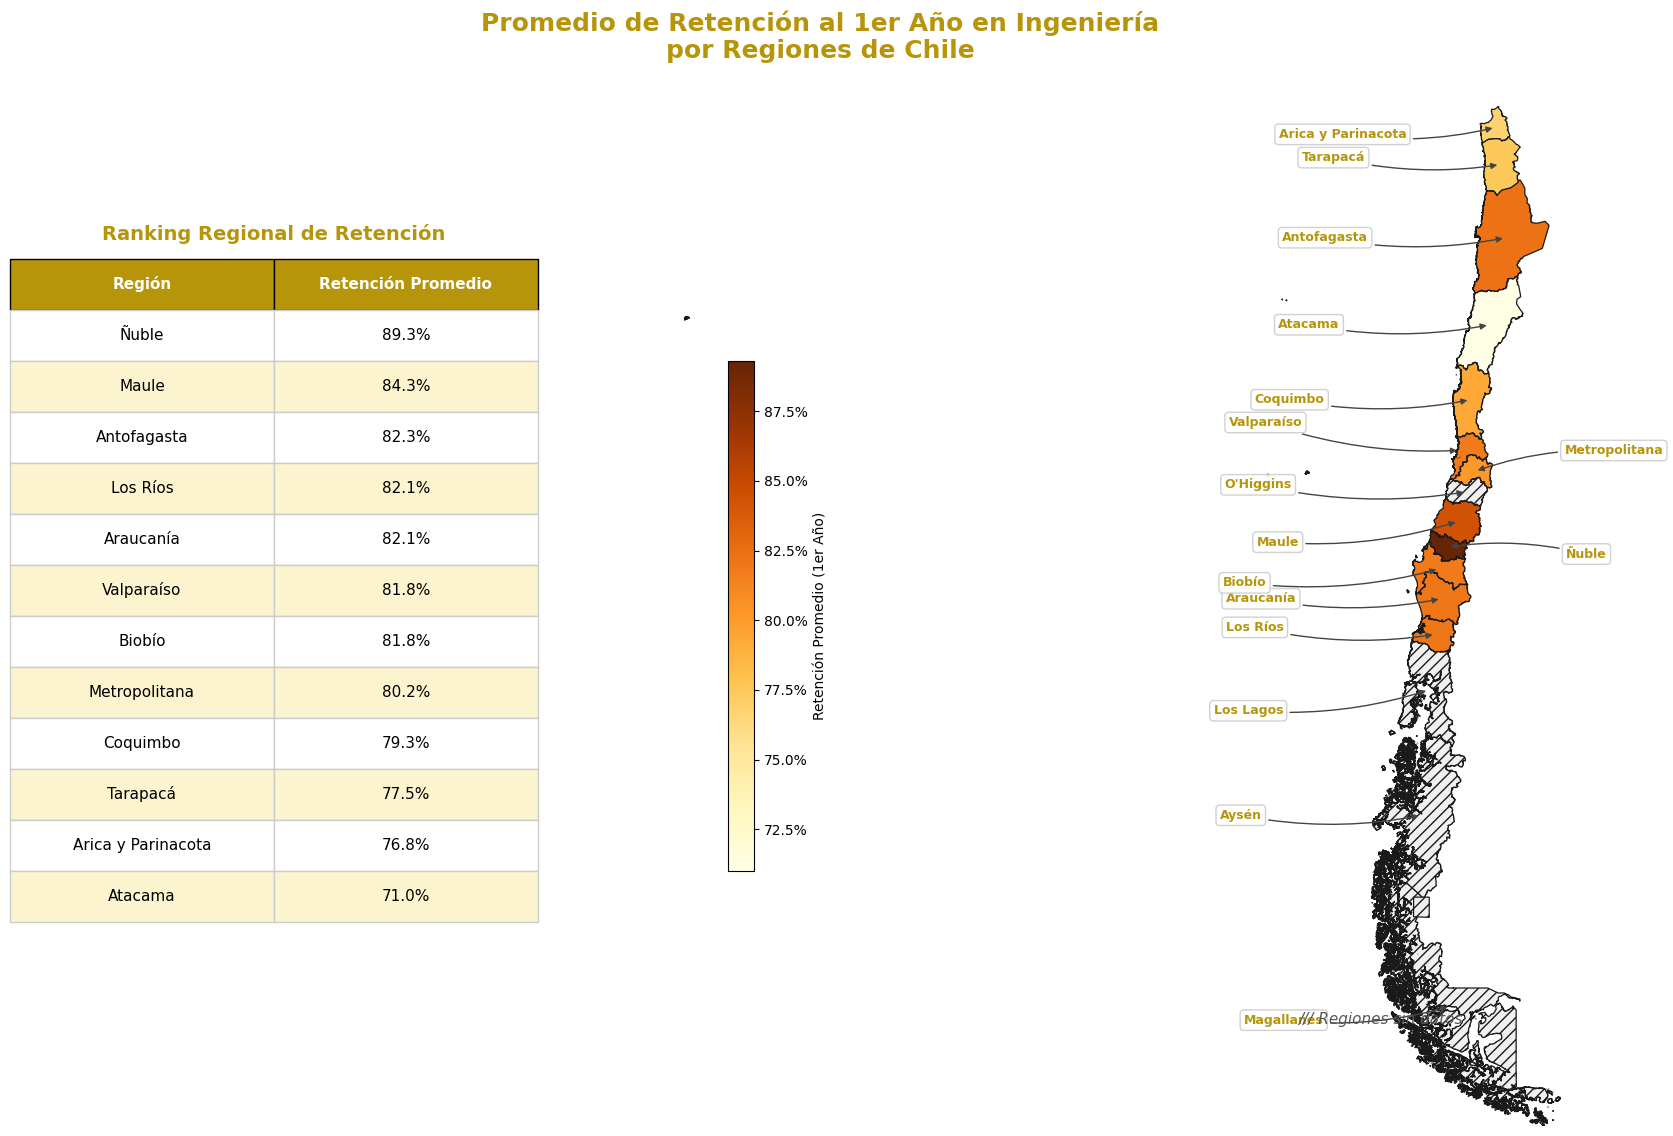

In [20]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import unicodedata
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CARGA DE DATOS Y CONFIGURACIÓN BASE
# ==============================================================================
mapa_chile = gpd.read_file('../regiones/Regional.shp', encoding='utf-8')
df = pd.read_csv('../todas_las_ingenierias_chile.csv', sep=';', encoding='utf-16')

region_map = {
    'UNIVERSIDAD FINIS TERRAE': 'Metropolitana', 'UNIVERSIDAD DIEGO PORTALES': 'Metropolitana', 'UNIVERSIDAD CENTRAL DE CHILE': 'Metropolitana', 'UNIVERSIDAD MAYOR': 'Metropolitana', 'UNIVERSIDAD SANTO TOMAS': 'Metropolitana', 'UNIVERSIDAD DE LAS AMERICAS': 'Metropolitana', 'UNIVERSIDAD ANDRES BELLO': 'Metropolitana', 'UNIVERSIDAD ADOLFO IBAÑEZ': 'Metropolitana', 'UNIVERSIDAD DE ARTES, CIENCIAS Y COMUNICACION - UNIACC': 'Metropolitana', 'UNIVERSIDAD AUTONOMA DE CHILE': 'Metropolitana', 'UNIVERSIDAD DE LOS ANDES': 'Metropolitana', 'UNIVERSIDAD CATOLICA CARDENAL RAUL SILVA HENRIQUEZ': 'Metropolitana', 'UNIVERSIDAD DEL DESARROLLO': 'Metropolitana', 'UNIVERSIDAD BERNARDO O´HIGGINS': 'Metropolitana', 'UNIVERSIDAD TECNOLOGICA DE CHILE INACAP': 'Metropolitana', 'UNIVERSIDAD ALBERTO HURTADO': 'Metropolitana', 'UNIVERSIDAD DE CHILE': 'Metropolitana', 'UNIVERSIDAD DE SANTIAGO DE CHILE': 'Metropolitana', 'UNIVERSIDAD TECNOLOGICA METROPOLITANA': 'Metropolitana', 'PONTIFICIA UNIVERSIDAD CATOLICA DE CHILE': 'Metropolitana',
    'UNIVERSIDAD DE VIÑA DEL MAR': 'Valparaíso', 'UNIVERSIDAD DE ACONCAGUA': 'Valparaíso', 'UNIVERSIDAD DE VALPARAISO': 'Valparaíso', 'UNIVERSIDAD DE PLAYA ANCHA DE CIENCIAS DE LA EDUCACION': 'Valparaíso', 'UNIVERSIDAD TECNICA FEDERICO SANTA MARIA': 'Valparaíso', 'PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO': 'Valparaíso',
    'UNIVERSIDAD ADVENTISTA DE CHILE': 'Ñuble',
    'UNIVERSIDAD SAN SEBASTIAN': 'Biobío', 'UNIVERSIDAD DEL BIO-BIO': 'Biobío', 'UNIVERSIDAD DE CONCEPCION': 'Biobío', 'UNIVERSIDAD CATOLICA DE LA SANTISIMA CONCEPCION': 'Biobío',
    'UNIVERSIDAD DE ANTOFAGASTA': 'Antofagasta', 'UNIVERSIDAD CATOLICA DEL NORTE': 'Antofagasta',
    'UNIVERSIDAD DE LA SERENA': 'Coquimbo',
    'UNIVERSIDAD DE TALCA': 'Maule', 'UNIVERSIDAD CATOLICA DEL MAULE': 'Maule',
    'UNIVERSIDAD DE LA FRONTERA': 'Araucanía', 'UNIVERSIDAD CATOLICA DE TEMUCO': 'Araucanía',
    'UNIVERSIDAD DE ATACAMA': 'Atacama',
    'UNIVERSIDAD ARTURO PRAT': 'Tarapacá',
    'UNIVERSIDAD DE TARAPACA': 'Arica y Parinacota',
    'UNIVERSIDAD DE LOS LAGOS': 'Los Lagos',
    'UNIVERSIDAD AUSTRAL DE CHILE': 'Los Ríos'
}

df['Región'] = df['Institución'].map(region_map)

def emparejar_region(nombre):
    if pd.isna(nombre): return 'Otra'
    n = unicodedata.normalize('NFKD', str(nombre)).encode('ASCII', 'ignore').decode('utf-8').lower()
    if 'bio' in n: return 'Biobío'
    if 'nuble' in n or 'ñuble' in n: return 'Ñuble'
    if 'metro' in n or 'santiago' in n: return 'Metropolitana'
    if 'valpara' in n: return 'Valparaíso'
    if 'antofa' in n: return 'Antofagasta'
    if 'atacama' in n: return 'Atacama'
    if 'coquimbo' in n: return 'Coquimbo'
    if 'higgins' in n: return "O'Higgins"
    if 'maule' in n: return 'Maule'
    if 'araucan' in n: return 'Araucanía'
    if 'rios' in n: return 'Los Ríos'
    if 'arica' in n: return 'Arica y Parinacota'
    if 'tarapac' in n: return 'Tarapacá'
    if 'lagos' in n: return 'Los Lagos'
    if 'aysen' in n: return 'Aysén'
    if 'magallanes' in n: return 'Magallanes'
    return 'Otra'

mapa_chile['Region_Simple'] = mapa_chile['Region'].apply(emparejar_region)

# Coordenadas maestras para evitar superposición
offsets = {
    'Arica y Parinacota': (-110, -5), 'Tarapacá': (-120, 5), 'Antofagasta': (-130, 0),
    'Atacama': (-130, 0), 'Coquimbo': (-130, 0), 'Valparaíso': (-140, 20),
    'Metropolitana': (100, 15), "O'Higgins": (-150, 5), 'Maule': (-130, -15),
    'Ñuble': (100, -5), 'Biobío': (-140, -10), 'Araucanía': (-130, 0),
    'Los Ríos': (-130, 5), 'Los Lagos': (-130, -15), 'Aysén': (-130, 0), 'Magallanes': (-120, -10)
}

# ==============================================================================
# MAPA 1: EMPLEABILIDAD AL 1ER AÑO
# ==============================================================================
df['Empleabilidad al 1er año'] = pd.to_numeric(df['Empleabilidad al 1er año'].str.replace('%', '').str.replace(',', '.'), errors='coerce')
datos_reg_1 = df.groupby('Región')['Empleabilidad al 1er año'].mean().reset_index()
datos_ord_1 = datos_reg_1.sort_values(by='Empleabilidad al 1er año', ascending=False).dropna()
tabla_datos_1 = [[row['Región'], f"{row['Empleabilidad al 1er año']:.1f}%"] for _, row in datos_ord_1.iterrows()]
mapa_data_1 = mapa_chile.merge(datos_reg_1, left_on='Region_Simple', right_on='Región', how='left')

fig1, (ax_t1, ax_m1) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 2.5]}, facecolor='white')
fig1.suptitle('Promedio de Empleabilidad al 1er Año en Ingeniería\npor Regiones de Chile', fontsize=18, fontweight='bold', color='#2C3E50', y=0.98)

ax_t1.axis('off')
ax_t1.set_title('Ranking Regional', fontweight='bold', color='#2C3E50', fontsize=14, y=0.86)
t1 = ax_t1.table(cellText=tabla_datos_1, colLabels=['Región', 'Promedio'], loc='center', cellLoc='center', bbox=[0.0, 0.20, 1.0, 0.65])
t1.auto_set_font_size(False); t1.set_fontsize(11)
for (row, col), cell in t1.get_celld().items():
    if row == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#2C3E50')
    else: cell.set_facecolor('#f4f6f9' if row % 2 == 0 else 'white'); cell.set_edgecolor('#cccccc')

mapa_data_1.plot(column='Empleabilidad al 1er año', cmap='Blues', linewidth=0.9, ax=ax_m1, edgecolor='#1a1a1a', legend=True,
               legend_kwds={'label': 'Empleabilidad Promedio (1er Año)', 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.02, 'format': '%.1f%%'},
               missing_kwds={"color": "#f0f0f0", "edgecolor": "#1a1a1a", "hatch": "///"})

minx, miny, maxx, maxy = mapa_data_1.total_bounds
ax_m1.set_xlim(minx - 1, maxx + 3.5); ax_m1.set_ylim(miny - 0.5, maxy + 0.5)

for idx, row in mapa_data_1.iterrows():
    nom = row['Region_Simple']
    if nom not in ['Otra', None] and pd.notna(nom):
        ax_m1.annotate(text=nom, xy=(row.geometry.centroid.x, row.geometry.centroid.y), xytext=offsets.get(nom, (-100, 0)), textcoords="offset points", fontsize=9, color='#2C3E50', fontweight='bold', ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="#ffffff", ec="#cccccc", alpha=0.9), arrowprops=dict(arrowstyle="-|>", color="#444444", lw=1, connectionstyle="arc3,rad=0.1"))

ax_m1.set_axis_off(); ax_m1.text(0.70, 0.10, '/// Regiones sin datos', transform=ax_m1.transAxes, fontsize=11, color='#555555', fontstyle='italic')
plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.05, wspace=0.1)
plt.show()

# ==============================================================================
# MAPA 2: EMPLEABILIDAD AL 2DO AÑO
# ==============================================================================
df['Empleabilidad al 2º Año'] = pd.to_numeric(df['Empleabilidad al 2º Año'].str.replace('%', '').str.replace(',', '.'), errors='coerce')
datos_reg_2 = df.groupby('Región')['Empleabilidad al 2º Año'].mean().reset_index()
datos_ord_2 = datos_reg_2.sort_values(by='Empleabilidad al 2º Año', ascending=False).dropna()
tabla_datos_2 = [[row['Región'], f"{row['Empleabilidad al 2º Año']:.1f}%"] for _, row in datos_ord_2.iterrows()]
mapa_data_2 = mapa_chile.merge(datos_reg_2, left_on='Region_Simple', right_on='Región', how='left')

fig2, (ax_t2, ax_m2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 2.5]}, facecolor='white')
fig2.suptitle('Promedio de Empleabilidad al 2º Año en Ingeniería\npor Regiones de Chile', fontsize=18, fontweight='bold', color='#1E5128', y=0.98) # Color verde oscuro

ax_t2.axis('off')
ax_t2.set_title('Ranking Regional', fontweight='bold', color='#1E5128', fontsize=14, y=0.86)
t2 = ax_t2.table(cellText=tabla_datos_2, colLabels=['Región', 'Promedio'], loc='center', cellLoc='center', bbox=[0.0, 0.20, 1.0, 0.65])
t2.auto_set_font_size(False); t2.set_fontsize(11)
for (row, col), cell in t2.get_celld().items():
    if row == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#1E5128')
    else: cell.set_facecolor('#f4f9f4' if row % 2 == 0 else 'white'); cell.set_edgecolor('#cccccc')

mapa_data_2.plot(column='Empleabilidad al 2º Año', cmap='Greens', linewidth=0.9, ax=ax_m2, edgecolor='#1a1a1a', legend=True,
               legend_kwds={'label': 'Empleabilidad Promedio (2º Año)', 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.02, 'format': '%.1f%%'},
               missing_kwds={"color": "#f0f0f0", "edgecolor": "#1a1a1a", "hatch": "///"})

ax_m2.set_xlim(minx - 1, maxx + 3.5); ax_m2.set_ylim(miny - 0.5, maxy + 0.5)

for idx, row in mapa_data_2.iterrows():
    nom = row['Region_Simple']
    if nom not in ['Otra', None] and pd.notna(nom):
        ax_m2.annotate(text=nom, xy=(row.geometry.centroid.x, row.geometry.centroid.y), xytext=offsets.get(nom, (-100, 0)), textcoords="offset points", fontsize=9, color='#1E5128', fontweight='bold', ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="#ffffff", ec="#cccccc", alpha=0.9), arrowprops=dict(arrowstyle="-|>", color="#444444", lw=1, connectionstyle="arc3,rad=0.1"))

ax_m2.set_axis_off(); ax_m2.text(0.70, 0.10, '/// Regiones sin datos', transform=ax_m2.transAxes, fontsize=11, color='#555555', fontstyle='italic')
plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.05, wspace=0.1)
plt.show()

# ==============================================================================
# MAPA 3: MAYORES SUELDOS Y CARRERAS TOP (BARRA VERTICAL)
# ==============================================================================
def valor_sueldo(texto):
    if pd.isna(texto) or texto == 's/i': return None
    t = str(texto).lower()
    if 'sobre $3 millones 500' in t or 'sobre 3 millones 500' in t: return 3.5
    if '3 millones a' in t and '3 millones 500' in t: return 3.25
    if '2 millones 500' in t and '3 millones' in t: return 2.75
    if '2 millones 400' in t: return 2.45
    if '2 millones 300' in t: return 2.35
    if '2 millones 200' in t: return 2.25
    if '2 millones 100' in t: return 2.15
    if '2 millones a' in t and '2 millones 100' in t: return 2.05
    if '1 millón 900' in t: return 1.95
    if '1 millón 800' in t: return 1.85
    if '1 millón 700' in t: return 1.75
    if '1 millón 600' in t: return 1.65
    if '1 millón 500' in t: return 1.55
    if '1 millón 400' in t: return 1.45
    if '1 millón 300' in t: return 1.35
    if '1 millón 200' in t: return 1.25
    if '1 millón 100' in t: return 1.15
    if '1 millón a' in t and '1 millón 100' in t: return 1.05
    return None

df['Sueldo_Num'] = df['Ingreso promedio al 4° año'].apply(valor_sueldo)
df_sueldos = df.dropna(subset=['Sueldo_Num'])

idx_max = df_sueldos.groupby('Región')['Sueldo_Num'].idxmax()
mejores_carreras = df_sueldos.loc[idx_max].sort_values(by='Sueldo_Num', ascending=False)

tabla_datos_sueldos = []
for _, row in mejores_carreras.iterrows():
    carrera = (row['Carrera'][:35] + '...') if len(row['Carrera']) > 35 else row['Carrera']
    tabla_datos_sueldos.append([row['Región'], carrera])

mapa_data_sueldo = mapa_chile.merge(mejores_carreras, left_on='Region_Simple', right_on='Región', how='left')

fig3, (ax_t3, ax_m3) = plt.subplots(1, 2, figsize=(18, 12), gridspec_kw={'width_ratios': [1.3, 2.5]}, facecolor='white')
fig3.suptitle('Mayores Sueldos en Ingeniería al 4º Año\npor Regiones de Chile', fontsize=18, fontweight='bold', color='#730000', y=0.98)

ax_t3.axis('off')
ax_t3.set_title('Carreras Mejor Pagadas por Región', fontweight='bold', color='#730000', fontsize=14, y=0.86)
t3 = ax_t3.table(cellText=tabla_datos_sueldos, colLabels=['Región', 'Carrera Top'], loc='center', cellLoc='center', bbox=[0.0, 0.20, 1.0, 0.65])
t3.auto_set_font_size(False); t3.set_fontsize(10)
for (row, col), cell in t3.get_celld().items():
    if row == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#730000')
    else: cell.set_facecolor('#fdf5f5' if row % 2 == 0 else 'white'); cell.set_edgecolor('#cccccc')

# --- CREACIÓN DE LA BARRA DE COLOR VERTICAL EN EL ESPACIO VACÍO ---
# [Izquierda, Abajo, Ancho, Alto] -> 5% a la derecha del inicio del mapa, centrado verticalmente
cax = ax_m3.inset_axes([0.05, 0.25, 0.03, 0.5]) 

mapa_data_sueldo.plot(column='Sueldo_Num', cmap='Reds', linewidth=0.9, ax=ax_m3, cax=cax, edgecolor='#1a1a1a', legend=True,
               legend_kwds={'label': 'Sueldo Promedio Máximo (Millones CLP)', 'format': '$%.2f M'},
               missing_kwds={"color": "#f0f0f0", "edgecolor": "#1a1a1a", "hatch": "///"})

ax_m3.set_xlim(minx - 1, maxx + 3.5); ax_m3.set_ylim(miny - 0.5, maxy + 0.5)

for idx, row in mapa_data_sueldo.iterrows():
    nom = row['Region_Simple']
    if nom not in ['Otra', None] and pd.notna(nom):
        ax_m3.annotate(text=nom, xy=(row.geometry.centroid.x, row.geometry.centroid.y), xytext=offsets.get(nom, (-100, 0)), textcoords="offset points", fontsize=9, color='#730000', fontweight='bold', ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="#ffffff", ec="#cccccc", alpha=0.9), arrowprops=dict(arrowstyle="-|>", color="#444444", lw=1, connectionstyle="arc3,rad=0.1"))

ax_m3.set_axis_off(); ax_m3.text(0.70, 0.10, '/// Regiones sin datos', transform=ax_m3.transAxes, fontsize=11, color='#555555', fontstyle='italic')
plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.05, wspace=0.1)
plt.show()

# ==============================================================================
# MAPA 4: RETENCIÓN AL 1ER AÑO (Tonos Amarillos)
# ==============================================================================
# 1. Limpiar columna
df['Retención de 1er año'] = pd.to_numeric(df['Retención de 1er año'].str.replace('%', '').str.replace(',', '.'), errors='coerce')

# 2. Calcular PROMEDIO por región
datos_reg_4 = df.groupby('Región')['Retención de 1er año'].mean().reset_index()
datos_ord_4 = datos_reg_4.sort_values(by='Retención de 1er año', ascending=False).dropna()

tabla_datos_retencion = []
for _, row in datos_ord_4.iterrows():
    tabla_datos_retencion.append([row['Región'], f"{row['Retención de 1er año']:.1f}%"])

mapa_data_4 = mapa_chile.merge(datos_reg_4, left_on='Region_Simple', right_on='Región', how='left')

# 3. Dibujar Figura
fig4, (ax_t4, ax_m4) = plt.subplots(1, 2, figsize=(18, 12), gridspec_kw={'width_ratios': [1.3, 2.5]}, facecolor='white')
fig4.suptitle('Promedio de Retención al 1er Año en Ingeniería\npor Regiones de Chile', fontsize=18, fontweight='bold', color='#B7950B', y=0.98) # Color Dorado/Amarillo oscuro

# --- TABLA ---
ax_t4.axis('off')
ax_t4.set_title('Ranking Regional de Retención', fontweight='bold', color='#B7950B', fontsize=14, y=0.86)
t4 = ax_t4.table(cellText=tabla_datos_retencion, colLabels=['Región', 'Retención Promedio'], loc='center', cellLoc='center', bbox=[0.0, 0.20, 1.0, 0.65])
t4.auto_set_font_size(False); t4.set_fontsize(11)
for (row, col), cell in t4.get_celld().items():
    if row == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#B7950B')
    else: cell.set_facecolor('#FCF3CF' if row % 2 == 0 else 'white'); cell.set_edgecolor('#cccccc')

# --- MAPA CON BARRA VERTICAL ---
cax4 = ax_m4.inset_axes([0.05, 0.25, 0.03, 0.5]) 
mapa_data_4.plot(column='Retención de 1er año', cmap='YlOrBr', linewidth=0.9, ax=ax_m4, cax=cax4, edgecolor='#1a1a1a', legend=True,
               legend_kwds={'label': 'Retención Promedio (1er Año)', 'format': '%.1f%%'},
               missing_kwds={"color": "#f0f0f0", "edgecolor": "#1a1a1a", "hatch": "///"})

ax_m4.set_xlim(minx - 1, maxx + 3.5); ax_m4.set_ylim(miny - 0.5, maxy + 0.5)

# Etiquetas de Regiones
for idx, row in mapa_data_4.iterrows():
    nom = row['Region_Simple']
    if nom not in ['Otra', None] and pd.notna(nom):
        ax_m4.annotate(text=nom, xy=(row.geometry.centroid.x, row.geometry.centroid.y), xytext=offsets.get(nom, (-100, 0)), textcoords="offset points", fontsize=9, color='#B7950B', fontweight='bold', ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="#ffffff", ec="#cccccc", alpha=0.9), arrowprops=dict(arrowstyle="-|>", color="#444444", lw=1, connectionstyle="arc3,rad=0.1"))

ax_m4.set_axis_off(); ax_m4.text(0.70, 0.10, '/// Regiones sin datos', transform=ax_m4.transAxes, fontsize=11, color='#555555', fontstyle='italic')
plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.05, wspace=0.1)
plt.show()